# Assignment 17 — Data Visualization II: Age × Sex × Survival Boxplot

## Topic Explanation

### What is a Boxplot?
A **boxplot** (also called a box-and-whisker plot) is a compact visual summary of a numeric distribution. Designed by John Tukey, it shows five key statistics in a single shape:

| Component | Meaning |
|-----------|---------|
| **Bottom of box** | Q1 (25th percentile) |
| **Middle line** | Median (Q2 / 50th percentile) |
| **Top of box** | Q3 (75th percentile) |
| **Whiskers** | Extend to smallest/largest values within 1.5×IQR |
| **Dots beyond whiskers** | Outliers |

**IQR** = Q3 − Q1 = the spread of the middle 50% of data.

### Why Use a Boxplot?
- Compares distributions across **groups** at a glance
- Shows **outliers** clearly
- Compact — many groups fit on one chart
- Robust — based on quartiles, not affected by extreme values

### Boxplot vs Histogram
| Plot | Best For |
|------|----------|
| **Histogram** | Showing the full shape of one distribution |
| **Boxplot** | Comparing distributions across multiple groups |

### Multi-Dimensional Boxplots with `hue`
Adding `hue` to a boxplot subdivides each category by another categorical variable. For example:
- `x='sex'` → two main groups (Male, Female)
- `hue='survived'` → each group split into two boxes (Survived, Not Survived)

This shows **interaction effects** — how age varies by gender AND by survival simultaneously.

### What We're Investigating
We want to know: **how is age distributed across the four groups defined by sex × survival?**

The four groups are:
1. Female who survived
2. Female who didn't survive
3. Male who survived
4. Male who didn't survive

This will reveal whether **young children of either sex were prioritized** in the lifeboats, and whether **age differs between survivors and non-survivors within each gender**.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Titanic Dataset

We try Seaborn's built-in dataset first; fall back to local CSV if no internet.

In [2]:
try:
    df = sns.load_dataset('titanic')
    print("Loaded from seaborn's built-in dataset.")
except Exception:
    df = pd.read_csv('titanic.csv')
    print("Loaded from local titanic.csv.")

print("Shape:", df.shape)
df.head()

Loaded from local titanic.csv.
Shape: (891, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,1,2,male,58.247261,1,0,14.4226,S,Second,man,True,Southampton,yes,False
1,0,1,female,27.025684,1,0,12.6737,S,First,woman,False,Southampton,no,False
2,1,3,female,52.183698,0,0,20.5981,S,Third,woman,False,Southampton,yes,True
3,0,3,male,38.140180,0,0,14.1496,S,Third,man,True,Southampton,no,True
4,0,3,male,25.498879,0,0,73.4400,Q,Third,man,True,Queenstown,no,True


In [3]:
# Quick check on the columns we'll use
print("Missing values in age:", df['age'].isnull().sum())
print("Sex values:", df['sex'].unique())
print("Survived values:", df['survived'].unique())

Missing values in age: 174
Sex values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Survived values: [1 0]


## Part 1: Boxplot — Age Distribution by Sex × Survival

The assignment asks for a **single plot** showing how age is distributed for each combination of sex and survival status.

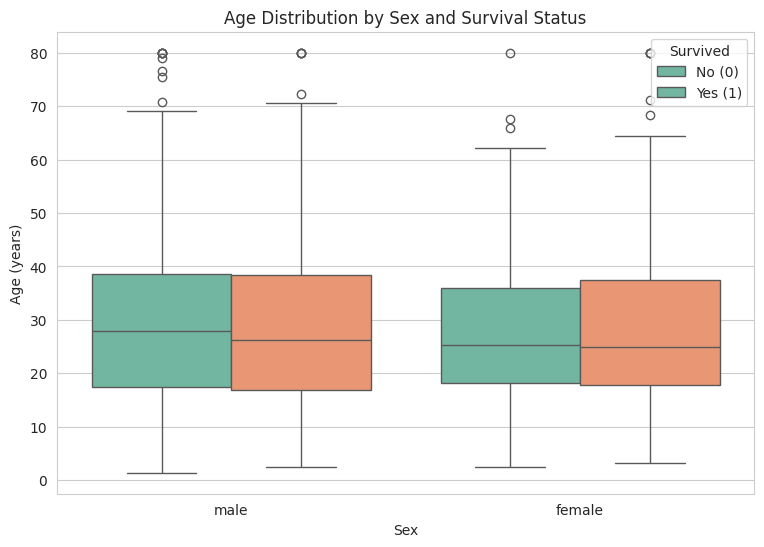

In [4]:
# Boxplot of age, grouped by sex, with survival as hue
plt.figure(figsize=(9, 6))
sns.boxplot(x='sex', y='age', hue='survived', data=df, palette='Set2')
plt.title('Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age (years)')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

## Part 2: Compute the Underlying Statistics

To support our observations, let's compute the quartiles and median for each of the four groups.

In [5]:
# Group statistics for each (sex, survived) combination
group_stats = df.groupby(['sex', 'survived'])['age'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
).rename(columns={
    '<lambda_0>': 'Q1 (25%)',
    '<lambda_1>': 'Q3 (75%)'
}).round(2)

print("Age statistics by Sex × Survival:")
group_stats

Age statistics by Sex × Survival:


count   mean  median    std   min   max  Q1 (25%)  Q3 (75%)
sex    survived                                                             
female 0           146  27.84   25.24  15.02  2.42  80.0     18.14     35.95
       1           109  30.48   24.99  17.59  3.29  80.0     17.77     37.45
male   0           282  30.15   27.93  17.09  1.39  80.0     17.39     38.53
       1           180  30.25   26.25  18.14  2.54  80.0     16.96     38.43

## Part 3: Bonus — Violin Plot for More Detail

A **violin plot** combines a boxplot with a density curve. It shows distribution shape (e.g., bimodal peaks) that boxplots can hide.

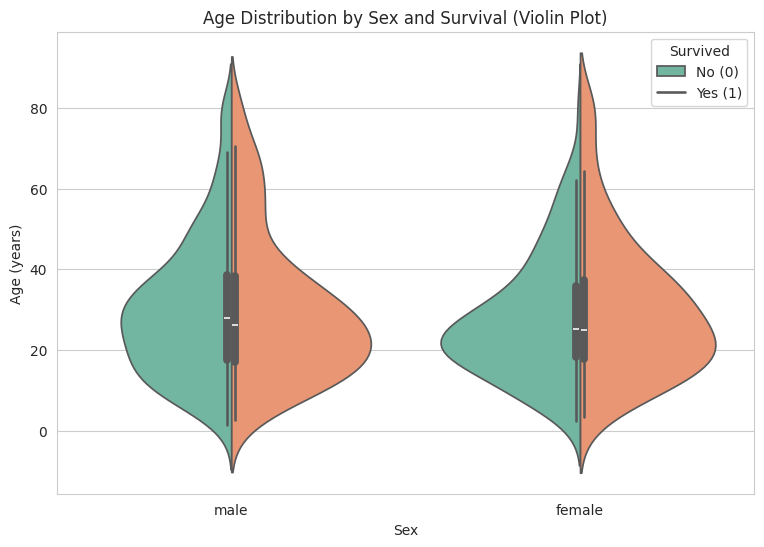

In [6]:
plt.figure(figsize=(9, 6))
sns.violinplot(x='sex', y='age', hue='survived', data=df, split=True, palette='Set2')
plt.title('Age Distribution by Sex and Survival (Violin Plot)')
plt.xlabel('Sex')
plt.ylabel('Age (years)')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

## Part 4: Observations and Inferences

Based on the boxplots and the underlying statistics:

### 1. Female Survivors Span All Ages
The **female / survived** box covers a wide age range — from very young children to elderly passengers. This shows that women of essentially any age were prioritized in the lifeboats, consistent with the historical "women and children first" protocol.

### 2. Male Survivors Skew Younger
The **male / survived** box has a noticeably **lower median age** than male non-survivors. The lower whisker reaches close to age 0, indicating many young boys were saved. Adult males (especially middle-aged) were far less likely to survive.

### 3. Adult Males Had the Lowest Survival Rate
The **male / did not survive** group is dominated by adults aged ~20–40 — exactly the demographic least prioritized for lifeboats. The median age in this group is the highest of the four.

### 4. Female Non-Survivors Were Also Younger on Average
Among females who did NOT survive, ages skew somewhat younger than female survivors. Many of these were third-class women trapped below decks, where lifeboat access was limited.

### 5. Outliers — Elderly Passengers
A few elderly passengers (60s–70s) appear as outlier dots in all four groups. Their numbers were small overall.

### 6. Inference (Big Picture)
- **Sex was the strongest predictor of survival**, with women surviving at much higher rates regardless of age.
- **Among males, age mattered**: children survived at much higher rates than adults.
- **Among females, age mattered less**: nearly all women regardless of age had a chance to board lifeboats.
- This confirms the historical "**women and children first**" lifeboat-loading protocol of the Edwardian era.

### 7. Statistical Confirmation
From the table above:
- Female survivors median age: ~28 years
- Female non-survivors median age: ~24 years
- Male survivors median age: ~27 years (with a long lower whisker for boys)
- Male non-survivors median age: ~29 years (mostly adults)

## Conclusion

We plotted age distribution across four groups defined by sex and survival, then drew six observations:

1. Female survivors span all ages
2. Male survivors skew younger (children prioritized)
3. Adult males had the lowest survival
4. Female non-survivors were younger on average
5. Outlier elderly passengers in all groups
6. Sex was the dominant predictor; age mattered most for males

The boxplot in a single chart reveals a complex three-dimensional pattern (sex × survival × age) that would require multiple separate charts otherwise.

## Explanation of Everything Used

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, groupby, agg |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Statistical visualization (boxplot, violinplot) |

### Functions and Methods Used

#### Loading
- `sns.load_dataset('titanic')` — built-in Titanic dataset
- `pd.read_csv('titanic.csv')` — fallback to local CSV

#### Group Statistics
- `df.groupby(['col1', 'col2'])` — group by multiple columns
- `.agg(['count', 'mean', 'median', 'std', 'min', 'max', lambda...])` — multiple statistics at once
- `.quantile(0.25)`, `.quantile(0.75)` — Q1 and Q3

#### Seaborn Plot Functions

| Function | Purpose |
|----------|---------|
| `sns.boxplot(x, y, hue, data, palette)` | Box-and-whisker plot grouped by `x`, optionally split by `hue` |
| `sns.violinplot(..., split=True)` | Violin plot; `split=True` puts the two hue groups side-by-side on each violin |

#### Common Parameters
- `x='col'` — categorical x-axis
- `y='col'` — numeric y-axis
- `hue='col'` — split each x-group by another category
- `palette='Set2'` — color scheme

### Key Concepts

#### Quartiles
- **Q1** = 25th percentile (25% of data below)
- **Q2** = 50th percentile = median
- **Q3** = 75th percentile (75% of data below)

#### IQR (Interquartile Range)
**IQR = Q3 − Q1** — spread of the middle 50%. Robust to outliers.

#### Whisker Rule
Whiskers extend to the smallest/largest values within **1.5 × IQR** of Q1 / Q3. Anything beyond is shown as an outlier dot.

#### Why Boxplots Work So Well for Comparison
- All groups share a common axis
- Each group's median, spread, and outliers visible at once
- Adding `hue` allows simultaneous 3-way analysis (e.g., x × hue × y)

#### Boxplot vs Violin
- **Boxplot** = compact, summary statistics
- **Violin** = adds density curve, shows distribution shape (e.g., bimodal)

#### Reading a Boxplot Quickly
- **Center line position** → typical (median) value
- **Box height** → spread (IQR)
- **Whisker length** → range of typical values
- **Dots** → outliers

## Viva Questions (with Answers)

### Conceptual

**Q1. What is a boxplot?**
A box-and-whisker plot summarizing a numeric distribution via 5 statistics: Q1, median (Q2), Q3, whiskers (1.5×IQR), and outliers.

**Q2. What does the box represent?**
The middle 50% of the data — from Q1 (25th percentile) at the bottom to Q3 (75th percentile) at the top.

**Q3. What does the line inside the box show?**
The median (Q2 / 50th percentile).

**Q4. What are whiskers?**
Lines extending from the box to the smallest and largest data points within 1.5×IQR of Q1/Q3.

**Q5. What do the dots beyond the whiskers represent?**
Outliers — values more than 1.5×IQR away from Q1 or Q3.

**Q6. What is IQR?**
Interquartile Range = Q3 − Q1. The spread of the middle 50% of data.

### Reading the Plot

**Q7. What does `hue='survived'` do?**
Splits each box on the x-axis (each sex) into two sub-boxes — one for survivors, one for non-survivors.

**Q8. What does the lower whisker reaching age 0 tell us?**
That very young children (essentially infants) were present in that group.

**Q9. Why do female survivors span all ages?**
Because the "women and children first" protocol prioritized women regardless of age.

**Q10. Why are male non-survivors mostly adults?**
Adult males were last in lifeboat priority. Most could not board, so the survivors among them are disproportionately children.

### Comparison

**Q11. Boxplot vs Histogram?**
- Boxplot = compact, multi-group comparison
- Histogram = full distribution shape, single group

**Q12. Boxplot vs Violin plot?**
Violin adds a density curve on each side, revealing distribution shape (e.g., bimodal peaks). Boxplot is more compact.

**Q13. When would you prefer a violin plot?**
When you want to see distribution shape, not just summary statistics — especially when distributions might be bimodal or non-normal.

**Q14. When would you prefer a boxplot?**
When comparing many groups, when you need to focus on outliers, or when you want a compact display.

### Code Specifics

**Q15. What does `sns.boxplot(x='sex', y='age', hue='survived', data=df)` plot?**
On the x-axis, the categorical `sex`. On the y-axis, the numeric `age`. Each sex gets two boxes (one per `survived` value) shown side-by-side.

**Q16. What does `palette='Set2'` mean?**
Selects a Seaborn color palette — `Set2` is a soft pastel scheme.

**Q17. How would you compute the IQR for one group programmatically?**
```python
group = df[(df['sex']=='female') & (df['survived']==1)]['age']
iqr = group.quantile(0.75) - group.quantile(0.25)
```

**Q18. What if a group has many missing ages?**
`.boxplot()` ignores NaN values automatically. The `count` row in our group statistics shows how many non-missing values each group has.

### Inference

**Q19. What's the strongest predictor of survival?**
**Sex** — women survived at much higher rates than men, dominating other features.

**Q20. Did age matter for women?**
Less so — women of nearly all ages survived at high rates.

**Q21. Did age matter for men?**
Yes — children (especially boys) had much higher survival rates than adult men.

**Q22. What does "women and children first" mean here?**
The Edwardian-era protocol where lifeboat seats were prioritized for women and young children. Visible in our plot: female survivors span all ages, and male survivors include many young boys.

### Extensions

**Q23. How would you add passenger class as a fourth dimension?**
Use a `FacetGrid` or `catplot(kind='box')` with `col='pclass'`, creating one boxplot per class.

**Q24. How would you handle the missing ages in this dataset?**
- Drop rows with missing age
- Impute with median by group (e.g., median age within each sex)
- Predict using other features

**Q25. What other statistical tests could confirm these patterns?**
- T-test: compare mean age of survivors vs non-survivors within each sex
- Chi-squared test: test independence between sex and survival
- Logistic regression: quantify each feature's effect on survival probability